In [ ]:
from google.colab import files
uploaded = files.upload()
file_name = list(uploaded.keys())[0]  # This gets the filename
print(f"Uploaded filename: {file_name}")

Saving fintech_data.csv to fintech_data (2).csv
Uploaded filename: fintech_data (2).csv


In [ ]:
import pandas as pd
import io

# Read the uploaded file
df = pd.read_csv(io.BytesIO(uploaded['fintech_data (2).csv']))

# Display the first few rows
df.head()

,Customer Id,Emp Title,Emp Length,Home Ownership,Annual Inc,Annual Inc Joint,Verification Status,Zip Code,Addr State,Avg Cur Bal,...,State,Funded Amount,Term,Int Rate,Grade,Issue Date,Pymnt Plan,Type,Purpose,Description
0,YidceGZkXHgxZmtceGY1XHhiOFx4MDN3XHg4MnxceGUxXH...,Lieutenant,10+ years,MORTGAGE,200000.0,NaN,Source Verified,117xx,NY,19404.0,...,NY,20000.0,60 months,0.1240,10,19 August 2019,False,Individual,debt_consolidation,Debt consolidation
1,YidUXHhhZlx4YTVcdFx4ZmYhRWpbXHhmMDRceDE4WE03XH...,Senior Film Management,10+ years,MORTGAGE,63000.0,NaN,Verified,441xx,OH,1946.0,...,OH,12000.0,60 months,0.0993,6,17 November 2017,False,Individual,credit_card,Credit card refinancing
2,YidceGY5KUBceGVkXHhiOW9ceGI2ZVx4ZmVceGYze1x4YW...,Machinist 2,1 year,OWN,30000.0,NaN,Verified,972xx,OR,22762.0,...,OR,10750.0,36 months,0.1952,23,15 March 2015,False,Individual,debt_consolidation,Debt consolidation
3,Yid3XHgwMVxyQVx4MTQxXHg5OFx4YjVceGMxPVx4OGZceD...,customer service,10+ years,RENT,20000.0,NaN,Verified,486xx,MI,1610.0,...,MI,8000.0,36 months,0.0789,1,15 March 2015,False,Individual,credit_card,Credit card refinancing
4,YidceGFhXHgxMn5cblx4OGJceDkwXHhjN1x4YjRMR1x4Yz...,Drivet,2 years,RENT,48000.0,NaN,Source Verified,334xx,FL,5341.0,...,FL,4200.0,36 months,0.0993,6,17 December 2017,False,Individual,debt_consolidation,Debt consolidation


In [ ]:
# Basic info
df.info()

# Check missing values per column
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27030 entries, 0 to 27029
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Customer Id          27030 non-null  object 
 1   Emp Title            24654 non-null  object 
 2   Emp Length           25173 non-null  object 
 3   Home Ownership       27030 non-null  object 
 4   Annual Inc           27030 non-null  float64
 5   Annual Inc Joint     1920 non-null   float64
 6   Verification Status  27030 non-null  object 
 7   Zip Code             27030 non-null  object 
 8   Addr State           27030 non-null  object 
 9   Avg Cur Bal          27030 non-null  float64
 10  Tot Cur Bal          27030 non-null  float64
 11  Loan Id              27030 non-null  int64  
 12  Loan Status          27030 non-null  object 
 13  Loan Amount          27030 non-null  float64
 14  State                27030 non-null  object 
 15  Funded Amount        27030 non-null 

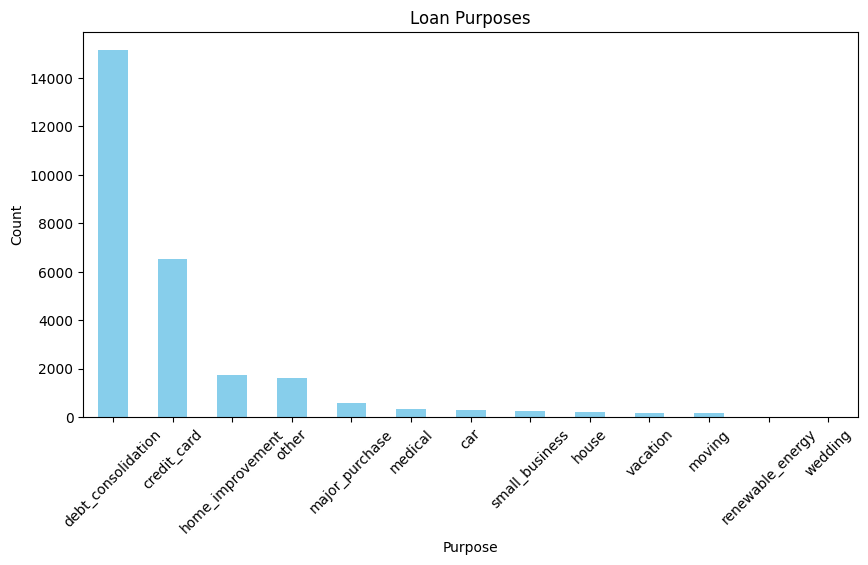

In [ ]:
import matplotlib.pyplot as plt

# Count loans by purpose
purpose_counts = df['Purpose'].value_counts()

# Plot
plt.figure(figsize=(10, 5))
purpose_counts.plot(kind='bar', color='skyblue')
plt.title('Loan Purposes')
plt.xlabel('Purpose')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

/tmp/ipython-input-10-1855795719.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Grade', y='Int Rate', data=df, palette='viridis')


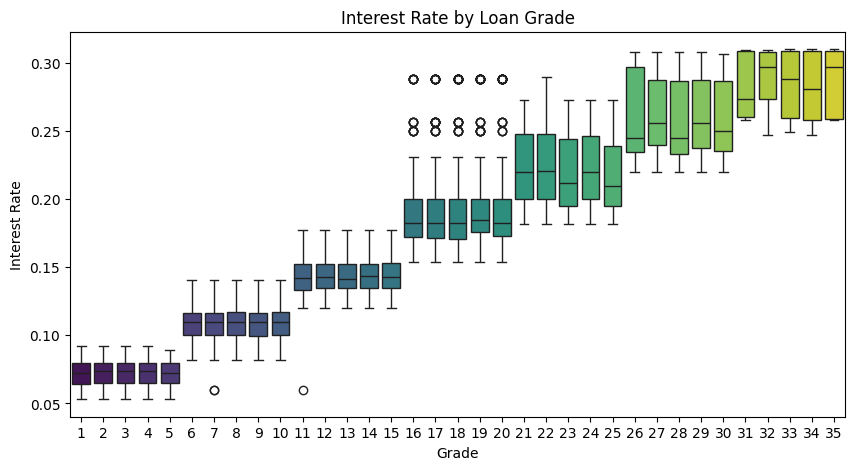

In [ ]:
import seaborn as sns

# Boxplot of Int Rate by Grade
plt.figure(figsize=(10, 5))
sns.boxplot(x='Grade', y='Int Rate', data=df, palette='viridis')
plt.title('Interest Rate by Loan Grade')
plt.xlabel('Grade')
plt.ylabel('Interest Rate')
plt.show()

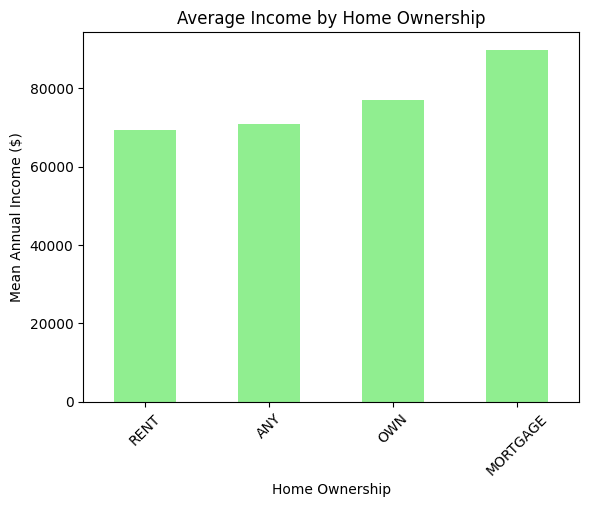

In [ ]:
# Group by home ownership
income_by_ownership = df.groupby('Home Ownership')['Annual Inc'].mean().sort_values()

# Plot
income_by_ownership.plot(kind='bar', color='lightgreen')
plt.title('Average Income by Home Ownership')
plt.xlabel('Home Ownership')
plt.ylabel('Mean Annual Income ($)')
plt.xticks(rotation=45)
plt.show()

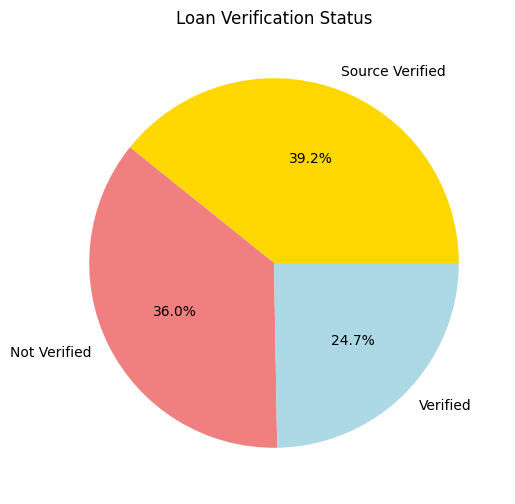

In [ ]:
status_counts = df['Verification Status'].value_counts()

# Pie chart
plt.figure(figsize=(6, 6))
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', colors=['gold', 'lightcoral', 'lightblue'])
plt.title('Loan Verification Status')
plt.show()

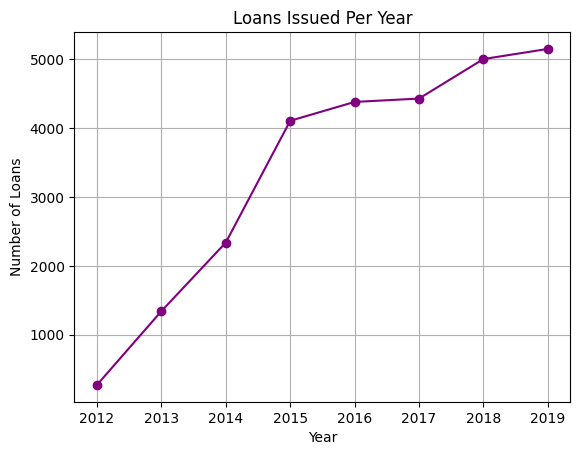

In [ ]:
# Convert to datetime and extract year/month
df['Issue Date'] = pd.to_datetime(df['Issue Date'])
df['Issue Year'] = df['Issue Date'].dt.year

# Count loans per year
loans_per_year = df['Issue Year'].value_counts().sort_index()

# Plot
loans_per_year.plot(kind='line', marker='o', color='purple')
plt.title('Loans Issued Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Loans')
plt.grid()
plt.show()

In [ ]:
# Clean column names
df.columns = df.columns.str.strip()  # Remove leading/trailing spaces
df.columns = df.columns.str.replace(' ', '_')  # Replace spaces with underscores
df.columns = df.columns.str.lower()  # Convert to lowercase

# Verify changes
print(df.columns.tolist())

['customer_id', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'annual_inc_joint', 'verification_status', 'zip_code', 'addr_state', 'avg_cur_bal', 'tot_cur_bal', 'loan_id', 'loan_status', 'loan_amount', 'state', 'funded_amount', 'term', 'int_rate', 'grade', 'issue_date', 'pymnt_plan', 'type', 'purpose', 'description', 'issue_year']


In [ ]:
df = df.set_index('loan_id')  # Sets 'loan_id' as the index
df.head(2)  # Verify (see 'loan_id' moved to the left as index)

,customer_id,emp_title,emp_length,home_ownership,annual_inc,annual_inc_joint,verification_status,zip_code,addr_state,avg_cur_bal,...,funded_amount,term,int_rate,grade,issue_date,pymnt_plan,type,purpose,description,issue_year
loan_id,,,,,,,,,,,,,,,,,,,,,
197838,YidceGZkXHgxZmtceGY1XHhiOFx4MDN3XHg4MnxceGUxXH...,Lieutenant,10+ years,MORTGAGE,200000.0,NaN,Source Verified,117xx,NY,19404.0,...,20000.0,60 months,0.1240,10,2019-08-19,False,Individual,debt_consolidation,Debt consolidation,2019
124597,YidUXHhhZlx4YTVcdFx4ZmYhRWpbXHhmMDRceDE4WE03XH...,Senior Film Management,10+ years,MORTGAGE,63000.0,NaN,Verified,441xx,OH,1946.0,...,12000.0,60 months,0.0993,6,2017-11-17,False,Individual,credit_card,Credit card refinancing,2017


In [ ]:
# Check for exact duplicate rows
duplicates = df.duplicated().sum()
print(f"Total duplicate rows: {duplicates}")

# Check for duplicate loan_id (should be 0 if set as index)
if 'loan_id' in df.columns:
    print(f"Duplicate loan_ids: {df['loan_id'].duplicated().sum()}")

Total duplicate rows: 0


In [ ]:
df = df.drop_duplicates()

In [ ]:
# Convert all categorical text to lowercase/uppercase
df['home_ownership'] = df['home_ownership'].str.upper()  # Example: "MORTGAGE"
df['verification_status'] = df['verification_status'].str.title()  # Example: "Verified"

In [ ]:
print(df['home_ownership'].value_counts())
print(df['verification_status'].value_counts())

home_ownership
MORTGAGE    13349
RENT        10517
OWN          3127
ANY            37
Name: count, dtype: int64
verification_status
Source Verified    10606
Not Verified        9741
Verified            6683
Name: count, dtype: int64


In [ ]:
df['home_ownership'] = df['home_ownership'].replace({'RENTER': 'RENT'})

In [ ]:
# Check columns with zero variance
for col in df.columns:
    if df[col].nunique() == 1:
        print(f"Column '{col}' has only 1 unique value: {df[col].iloc[0]}")

In [ ]:
df = df.drop(columns=['pymnt_plan'])  # Example (if all False)

In [ ]:
# Summary stats for numerical columns
print(df[['annual_inc', 'int_rate', 'loan_amount']].describe())

         annual_inc      int_rate   loan_amount
count  2.703000e+04  25819.000000  27030.000000
mean   8.038403e+04      0.130201  15375.772290
std    1.059586e+05      0.048821   9437.017325
min    2.000000e+03      0.053100   1000.000000
25%    4.784000e+04      0.091700   8000.000000
50%    6.631050e+04      0.124900  13000.000000
75%    9.500000e+04      0.159900  20000.000000
max    7.691779e+06      0.309900  40000.000000


In [ ]:
# Cap income at 99th percentile
income_cap = df['annual_inc'].quantile(0.99)
df['annual_inc'] = df['annual_inc'].clip(upper=income_cap)

In [ ]:
# Ensure uniform datetime format
df['issue_date'] = pd.to_datetime(df['issue_date'], errors='coerce')  # 'coerce' invalid dates to NaT
print(df['issue_date'].dt.year.value_counts())  # Check years for anomalies

issue_date
2019    5152
2018    5005
2017    4431
2016    4382
2015    4108
2014    2339
2013    1342
2012     271
Name: count, dtype: int64


In [ ]:
df = df.dropna(subset=['issue_date'])

In [ ]:
print(df['purpose'].value_counts())

purpose
debt_consolidation    15142
credit_card            6539
home_improvement       1742
other                  1616
major_purchase          573
medical                 335
car                     276
small_business          241
house                   191
vacation                184
moving                  164
renewable_energy         19
wedding                   8
Name: count, dtype: int64


In [ ]:
df['purpose'] = df['purpose'].replace({'credit_card': 'credit card', 'debt_consolidation': 'debt consolidation'})

In [ ]:
# Example: Is `emp_title` missing more for low-income borrowers?
mask = df['emp_title'].isnull()
print(df[mask]['annual_inc'].describe())  # Compare income stats for missing vs non-missing

count      2376.000000
mean      58118.914632
std       43494.743956
min        2200.000000
25%       30000.000000
50%       48006.000000
75%       70066.080000
max      275000.000000
Name: annual_inc, dtype: float64


In [ ]:
import numpy as np
import pandas as pd
from datetime import datetime

## 1. Month Number Column
if 'date' in df.columns:
    # Convert to datetime if not already
    df['date'] = pd.to_datetime(df['date'])
    df['month_number'] = df['date'].dt.month.astype('int8')  # Efficient storage with int8

## 2. Salary Can Cover Column
if 'income' in df.columns and 'loan_amount' in df.columns:
    # Compare annual income to loan amount (assuming income is annual)
    df['salary_can_cover'] = (df['income'] >= df['loan_amount']).astype('int8')  # Boolean as 0/1

## 3. Letter Grade Column
if 'grade' in df.columns:
    # Ensure grades are uppercase and valid
    df['grade'] = df['grade'].str.upper()
    valid_grades = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
    df['grade'] = pd.Categorical(df['grade'], categories=valid_grades, ordered=True)

## 4. Installment per Month Column
if all(col in df.columns for col in ['loan_amount', 'int_rate', 'term']):
    # Extract numeric months from term (assuming format like "36 months")
    df['term_months'] = df['term'].str.extract('(\d+)').astype(int)

    # Calculate monthly installment
    monthly_rate = df['int_rate'] / 100 / 12  # Convert APR to monthly decimal
    principal = df['loan_amount']
    periods = df['term_months']

    df['installment_per_month'] = (
        principal * monthly_rate * (1 + monthly_rate)**periods /
        ((1 + monthly_rate)**periods - 1)
    ).round(2)

## Encoding Categorical Features
# Create lookup table for categorical encodings
lookup_table = {}

for col in df.select_dtypes(include=['object', 'category']).columns:
    if df[col].nunique() < 20:  # For categorical columns
        # Ordinal encoding for ordered categories
        if col == 'grade':  # Already properly ordered
            lookup_table[col] = dict(zip(valid_grades, range(len(valid_grades))))
            df[f'{col}_encoded'] = df[col].cat.codes
        else:
            # One-hot encoding for other categoricals
            dummies = pd.get_dummies(df[col], prefix=col)
            df = pd.concat([df, dummies], axis=1)
            lookup_table[col] = {val: i for i, val in enumerate(df[col].unique())}

## Normalization
# Identify features needing normalization
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
to_normalize = []

for col in numeric_cols:
    if df[col].nunique() > 10:  # Continuous variables
        skewness = df[col].skew()
        if abs(skewness) > 1:  # Highly skewed
            to_normalize.append((col, 'log'))
        elif abs(skewness) > 0.5:  # Moderately skewed
            to_normalize.append((col, 'standard'))
        else:
            to_normalize.append((col, 'minmax'))

# Apply normalization
for col, method in to_normalize:
    if method == 'log':
        # Add small constant to avoid log(0)
        df[f'{col}_norm'] = np.log1p(df[col])
    elif method == 'standard':
        df[f'{col}_norm'] = (df[col] - df[col].mean()) / df[col].std()
    else:  # minmax
        df[f'{col}_norm'] = (df[col] - df[col].min()) / (df[col].max() - df[col].min())

# Display the lookup table
print("Categorical Encoding Lookup Table:")
for col, mapping in lookup_table.items():
    print(f"\n{col}:")
    for val, code in mapping.items():
        print(f"  {val} → {code}")

# Show normalization summary
print("\nNormalization Applied:")
for col, method in to_normalize:
    print(f"  {col}: {method} scaling")

# Show the first few rows of transformed data
print("\nTransformed Data Preview:")
df.head()

Categorical Encoding Lookup Table:

Emp Length:
  10+ years → 0
  1 year → 1
  2 years → 2
  nan → 3
  < 1 year → 4
  3 years → 5
  5 years → 6
  4 years → 7
  7 years → 8
  6 years → 9
  9 years → 10
  8 years → 11

Home Ownership:
  MORTGAGE → 0
  OWN → 1
  RENT → 2
  ANY → 3

Verification Status:
  Source Verified → 0
  Verified → 1
  Not Verified → 2

Loan Status:
  Current → 0
  Charged Off → 1
  Fully Paid → 2
  In Grace Period → 3
  Late (31-120 days) → 4
  Late (16-30 days) → 5
  Default → 6

Term:
   60 months → 0
   36 months → 1

Type:
  Individual → 0
  INDIVIDUAL → 1
  DIRECT_PAY → 2
  JOINT → 3
  Joint App → 4

Purpose:
  debt_consolidation → 0
  credit_card → 1
  home_improvement → 2
  medical → 3
  other → 4
  small_business → 5
  moving → 6
  car → 7
  major_purchase → 8
  house → 9
  vacation → 10
  wedding → 11
  renewable_energy → 12

Normalization Applied:
  Annual Inc: log scaling
  Annual Inc Joint: log scaling
  Avg Cur Bal: log scaling
  Tot Cur Bal: log scalin

,Customer Id,Emp Title,Emp Length,Home Ownership,Annual Inc,Annual Inc Joint,Verification Status,Zip Code,Addr State,Avg Cur Bal,...,Purpose_wedding,Annual Inc_norm,Annual Inc Joint_norm,Avg Cur Bal_norm,Tot Cur Bal_norm,Loan Id_norm,Loan Amount_norm,Funded Amount_norm,Int Rate_norm,Grade_norm
0,YidceGZkXHgxZmtceGY1XHhiOFx4MDN3XHg4MnxceGUxXH...,Lieutenant,10+ years,MORTGAGE,200000.0,NaN,Source Verified,117xx,NY,19404.0,...,False,12.206078,NaN,9.873286,12.706463,0.731920,0.490009,0.490009,-0.127006,-0.135266
1,YidUXHhhZlx4YTVcdFx4ZmYhRWpbXHhmMDRceDE4WE03XH...,Senior Film Management,10+ years,MORTGAGE,63000.0,NaN,Verified,441xx,OH,1946.0,...,False,11.050906,NaN,7.574045,10.569469,0.460943,-0.357716,-0.357716,-0.632934,-0.767888
2,YidceGY5KUBceGVkXHhiOW9ceGI2ZVx4ZmVceGYze1x4YW...,Machinist 2,1 year,OWN,30000.0,NaN,Verified,972xx,OR,22762.0,...,False,10.308986,NaN,10.032892,11.824607,0.399290,-0.490173,-0.490173,1.331377,1.920755
3,Yid3XHgwMVxyQVx4MTQxXHg5OFx4YjVceGMxPVx4OGZceD...,customer service,10+ years,RENT,20000.0,NaN,Verified,486xx,MI,1610.0,...,False,9.903538,NaN,7.384610,9.176059,0.233550,-0.781579,-0.781579,-1.050785,-1.558665
4,YidceGFhXHgxMn5cblx4OGJceDkwXHhjN1x4YjRMR1x4Yz...,Drivet,2 years,RENT,48000.0,NaN,Source Verified,334xx,FL,5341.0,...,False,10.778977,NaN,8.583355,10.780414,0.075846,-1.184248,-1.184248,-0.632934,-0.767888
